Importamos bibliotecas necesarias

In [11]:

import numpy as np
import tensorflow as tf
%matplotlib inline
import matplotlib.pyplot as plt
from keras import Model
from keras.models import Sequential
from keras.losses import categorical_crossentropy
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout, Activation
from sklearn.model_selection import train_test_split
from keras import datasets
from keras.utils import to_categorical
import pygad
import random
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
from keras.models import load_model

Preparamos los datos

In [6]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()


x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# normalización de los datos
x_train /= 255
x_test /= 255

# reshape de los datos para que sean compatibles con la red neuronal
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, 
    y_train, 
    test_size=10000, # 1/6 del total de entrenamiento
    random_state=42, 
    stratify=y_train
)

# one-hot encoding de las etiquetas
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

Definimos los rangos de la estructura genética 

In [ ]:
gene_space = [
    {'low': 0.0, 'high': 0.3},          # Learning rate
    {'low': 1, 'high': 129},            # Tamaño del primer filtro
    {'low': 1, 'high': 129},            # Tamaño del segundo filtro
    [0,1,2,3,4,5],                      # Función de activación
    [0,1,2],                            # Tamaño del kernel de convolución
    [0,1,2],                            # Tamaño del kernel de pooling
    [0,1,2],                            # Stride de convolución
    [0,1,2],                            # Stride de pooling
    {'low': 1, 'high': 129},            # Número de neuronas en la capa densa
    {'low': 0.0, 'high': 1.0}           # Dropout rate
]

Establecemos la función para decodificar el cromosoma

In [32]:
def decode_chromosome(chromosome):
    learning_rate = chromosome[0]
    filter_size_1 = int(chromosome[1])
    filter_size_2 = int(chromosome[2])
    activation_function = ['relu', 'sigmoid', 'tanh', 'elu', 'selu', 'softmax'][int(chromosome[3])]
    kernel_size_conv = [3,5,7][int(chromosome[4])]
    kernel_size_pool = [3,5,7][int(chromosome[5])]
    stride_conv = [1,2,3][int(chromosome[6])]
    stride_pool = [1,2,3][int(chromosome[7])]
    dense_neurons = int(chromosome[8])
    dropout_rate = chromosome[9]
    
    return {
        'learning_rate': learning_rate,
        'filter_size_1': filter_size_1,
        'filter_size_2': filter_size_2,
        'activation_function': activation_function,
        'kernel_size_conv': kernel_size_conv,
        'kernel_size_pool': kernel_size_pool,
        'stride_conv': stride_conv,
        'stride_pool': stride_pool,
        'dense_neurons': dense_neurons,
        'dropout_rate': dropout_rate
    }

Ahora definimos la función de fitnes o aptitud

In [ ]:
def fitness_function(ga_instance, solution, solution_idx):

    try:
        '''Obtenemos los parámetros del cromosoma decodificado y construimos el modelo de red neuronal con esos parámetros. 
        Luego, entrenamos el modelo con los datos de entrenamiento y evaluamos su precisión en el conjunto de validación. 
        Finalmente, devolvemos la precisión de validación como la aptitud del cromosoma.
        '''
        params = decode_chromosome(solution)
        ''' Construcción del modelo de red neuronal con los parámetros decodificados.'''
        model = Sequential()

        ''' Agregamos capas al modelo utilizando los parámetros decodificados. '''
        model.add(Conv2D(params['filter_size_1'],           # Tamaño del primer filtro
                        (params['kernel_size_conv'],       # Tamaño del kernel de convolución
                        params['kernel_size_conv']),      
                        strides=(params['stride_conv'],    # Stride de convolución
                                params['stride_conv']),    # 
                                activation=params['activation_function'],  # Función de activación
                                padding='same',
                                input_shape=(28, 28, 1)))                  # Tamaño de la imagen de entrada
        
        ''' Agregamos una capa de pooling al modelo utilizando los parámetros decodificados. '''
        model.add(MaxPool2D(pool_size=(params['kernel_size_pool'],      # Tamaño del kernel de pooling
                                    params['kernel_size_pool']),     
                            strides=(params['stride_pool'],         # Stride de pooling
                                    params['stride_pool']),
                                    padding='same'))
        
        ''' Agregamos una segunda capa de convolución al modelo utilizando los parámetros decodificados. '''
        model.add(Conv2D(params['filter_size_2'], 
                        (params['kernel_size_conv'],        # Tamaño del kernel de convolución
                        params['kernel_size_conv']), 
                        strides=(params['stride_conv'],     # Stride de convolución
                                params['stride_conv']), 
                                padding='same',
                                activation=params['activation_function']))    # Función de activación
        
        ''' Agregamos una capa de pooling al modelo utilizando los parámetros decodificados. '''
        model.add(MaxPool2D(pool_size=(params['kernel_size_pool'],     # Tamaño del kernel de pooling
                                    params['kernel_size_pool']),    
                            strides=(params['stride_pool'],     # Stride de pooling
                                    params['stride_pool']),
                                    padding='same'))
        
        ''' Aplanamos la salida de las capas convolucionales para conectarla con la capa densa. '''
        model.add(Flatten())

        ''' Agregamos una capa densa al modelo utilizando los parámetros decodificados. '''
        model.add(Dense(params['dense_neurons'],                    # Número de neuronas en la capa densa
                        activation=params['activation_function']))  # Función de activación
        
        ''' Agregamos una capa de dropout al modelo utilizando los parámetros decodificados. '''
        model.add(Dropout(params['dropout_rate']))             # Dropout rate

        ''' Agregamos la capa de salida al modelo. '''
        model.add(Dense(10, activation='softmax'))             # Capa de salida con 10 neuronas (una por clase) y función de activación softmax
        


        ''' Compilamos el modelo utilizando el optimizador Adam con la tasa de aprendizaje decodificada y la función de 
        pérdida categorical_crossentropy. '''
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
                    loss=categorical_crossentropy,
                    metrics=['accuracy'])
        
        history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=0)
        fitness = history.history['val_accuracy'][-1]
    except Exception as e:
        print(f"Error en la evaluación del cromosoma {solution_idx}: {e}")
        fitness = 0.0  # Asignar una aptitud baja en caso de error

    tf.keras.backend.clear_session()      # Limpiar la sesión de Keras para liberar memoria después de cada evaluación 
    return fitness  # Devolvemos la precisión de validación como la aptitud del cromosoma

Ahora definimos la función del main 

Ejecutando algoritmo genético...
Mejor solución encontrada:  [2.48633108e-02 5.92793746e+01 2.15185785e+01 5.00000000e+00
 0.00000000e+00 1.00000000e+00 1.00000000e+00 2.00000000e+00
 1.14678776e+02 4.75865159e-01]
Fitness de la mejor solución:  0.8226666450500488
Parámetros de la mejor solución:  {'learning_rate': np.float64(0.024863310819918015), 'filter_size_1': 59, 'filter_size_2': 21, 'activation_function': 'softmax', 'kernel_size_conv': 3, 'kernel_size_pool': 5, 'stride_conv': 2, 'stride_pool': 3, 'dense_neurons': 114, 'dropout_rate': np.float64(0.47586515890678593)}


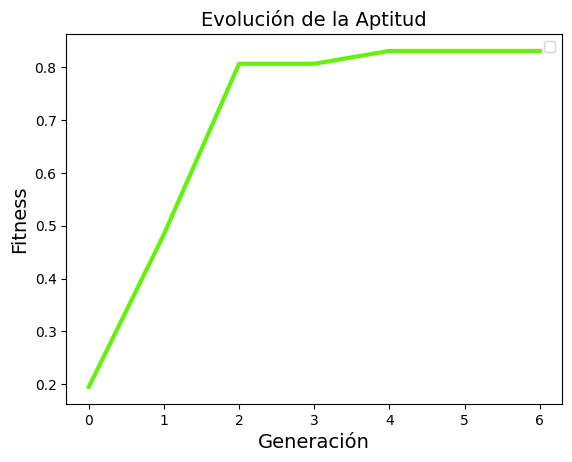

In [34]:
def main():
    # Aquí iría el código para ejecutar el algoritmo genético utilizando la función de aptitud definida anteriormente.
    print("Ejecutando algoritmo genético...")
    ga = pygad.GA(num_generations=6,
                   num_parents_mating=2,
                   fitness_func=fitness_function,
                   sol_per_pop=10,
                   num_genes=len(gene_space),
                   gene_space=gene_space,
                   crossover_probability=0.8,
                   mutation_probability=0.1)
    ga.run()
    solution, solution_fitness, _ = ga.best_solution()
    solution_decoded = decode_chromosome(solution)
    print("Mejor solución encontrada: ", solution)
    print("Fitness de la mejor solución: ", solution_fitness)
    print("Parámetros de la mejor solución: ", solution_decoded)

    # gráficoico de la evolución de la aptitud a lo largo de las generaciones
    ga.plot_fitness(title="Evolución de la Aptitud", xlabel="Generación", ylabel="Fitness")
if __name__ == "__main__":
    main()

In [ ]:
best_sol = {'learning_rate': np.float64(0.024863310819918015), 
            'filter_size_1': 59, 
            'filter_size_2': 21, 
            'activation_function': 'softmax', 
            'kernel_size_conv': 3, 
            'kernel_size_pool': 5, 
            'stride_conv': 2, 
            'stride_pool': 3, 
            'dense_neurons': 114, 
            'dropout_rate': np.float64(0.47586515890678593)}

# reconstruimos la estructura de la mejor solución

mejor_modelo = Sequential()
# Bloque 1
mejor_modelo.add(Conv2D(best_sol['filter_size_1'], (best_sol['kernel_size_conv'], best_sol['kernel_size_conv']), 
                            padding='same', input_shape=(28, 28, 1)))
    
mejor_modelo.add(Activation(best_sol['activation_function']))
mejor_modelo.add(MaxPool2D(pool_size=(best_sol['kernel_size_pool'], best_sol['kernel_size_pool']), padding='same'))
# Bloque 2
mejor_modelo.add(Conv2D(best_sol['filter_size_2'], (best_sol['kernel_size_conv'], best_sol['kernel_size_conv']), padding='same'))
    
mejor_modelo.add(Activation(best_sol['activation_function']))
mejor_modelo.add(Flatten())
# Capas densas
mejor_modelo.add(Dense(best_sol['dense_neurons']))
mejor_modelo.add(Activation(best_sol['activation_function']))
mejor_modelo.add(Dropout(best_sol['dropout_rate']))
mejor_modelo.add(Dense(10, activation='softmax'))

# compilamos
mejor_modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_sol['learning_rate']),
                         loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamos nuevamente el modelo
mejor_modelo.fit(x_train, y_train, epochs=20, batch_size=128, 
                    validation_data=(x_val, y_val), verbose=1)

# probamos el modelo en el conjunto de prueba
test_loss, test_acc = mejor_modelo.evaluate(x_test, y_test, verbose=1)

print(f"\nAccuracy Final en Test: {test_acc:.4f}")

# guardamos
mejor_modelo.save("modelo_final_fashion_mnist.keras")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.2837 - loss: 1.7313 - val_accuracy: 0.6497 - val_loss: 1.0211
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.4586 - loss: 1.3277 - val_accuracy: 0.7918 - val_loss: 0.7069
Epoch 3/20
  4/391 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.5085 - loss: 1.1735

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

 Métricas
Accuracy : 0.8583
Precision: 0.8573
Recall   : 0.8583
F1-score : 0.8558

 Reporte
              precision    recall  f1-score   support

           0       0.74      0.87      0.80      1000
           1       0.97      0.99      0.98      1000
           2       0.78      0.75      0.77      1000
           3       0.83      0.92      0.87      1000
           4       0.77      0.69      0.72      1000
           5       0.98      0.97      0.97      1000
           6       0.64      0.54      0.59      1000
           7       0.89      0.99      0.94      1000
           8       0.98      0.96      0.97      1000
           9       0.99      0.90      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



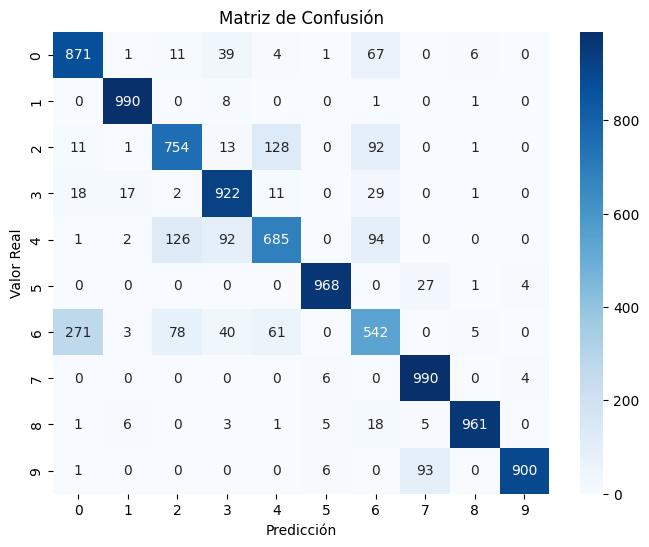

In [10]:
mejor_modelo = load_model("modelo_final_fashion_mnist.keras")

y_pred_prob = mejor_modelo.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Etiquetas reales
y_true = np.argmax(y_test, axis=1)

# Accuracy
accuracy = np.mean(y_pred == y_true)

# Precision, Recall, F1 (promedio macro)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("\n Métricas")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Reporte por clase
print("\n Reporte")
print(classification_report(y_true, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()